# Machine Learning 2025W — Exercise 0  
### Dataset Description and Exploration (adult)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---


## 1. Setup

In [8]:
from scipy.io import arff
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

file_path = '../datasets/dataset_adult_2.arff'

# Read ARFF file, skip lines starting with '%' or '@'
with open(file_path, 'r') as f:
    lines = [line.strip() for line in f if not line.startswith('@') and not line.startswith('%') and line.strip() != '']

# Split each line by comma
data = [line.split(',') for line in lines]

# Column names from ARFF attributes
columns = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week',
           'workclass','education','marital-status','occupation','relationship',
           'race','sex','native-country','class']

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Convert numeric columns
numeric_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Convert categorical columns
categorical_cols = [c for c in df.columns if c not in numeric_cols]
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.astype('category'))

df.head(20)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
0,19,134974.0,10,0.0,0.0,20,nan,Some-college,Never-married,nan,Own-child,White,Female,United-States,<=50K
1,41,195096.0,13,0.0,0.0,50,Self-emp-inc,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
2,31,152109.0,9,0.0,0.0,50,Private,HS-grad,Never-married,Exec-managerial,Not-in-family,White,Male,United-States,<=50K
3,40,202872.0,12,0.0,0.0,45,Private,Assoc-acdm,Never-married,Adm-clerical,Own-child,White,Female,United-States,<=50K
4,35,98989.0,5,0.0,0.0,38,nan,9th,Divorced,nan,Own-child,Amer-Indian-Eskimo,Male,United-States,<=50K
5,47,200808.0,8,0.0,0.0,35,Local-gov,12th,Married-civ-spouse,Adm-clerical,Husband,White,Male,Puerto-Rico,<=50K
6,23,99408.0,10,0.0,0.0,40,Private,Some-college,Divorced,Adm-clerical,Own-child,White,Female,United-States,<=50K
7,62,271464.0,14,0.0,0.0,30,Self-emp-not-inc,Masters,Separated,Farming-fishing,Not-in-family,White,Male,United-States,<=50K
8,62,188650.0,4,0.0,0.0,10,nan,7th-8th,Married-civ-spouse,nan,Husband,White,Male,United-States,<=50K
9,27,162312.0,10,0.0,0.0,50,State-gov,Some-college,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,South,<=50K


## 2. Load old Dataset

In [10]:
file_path = '../datasets/dataset_adult.arff'

data, meta = arff.loadarff(file_path)
df_old = pd.DataFrame(data)

for col in df_old.select_dtypes(['object']).columns:
        df_old[col] = df_old[col].str.decode('utf-8')

print("Dataset shape:", df_old.shape)
df_old.head(20)

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
5,2,Private,284582.0,Masters,14.0,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,2,United-States,<=50K
6,3,Private,160187.0,9th,5.0,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,0,Jamaica,<=50K
7,3,Self-emp-not-inc,209642.0,HS-grad,9.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,2,United-States,>50K
8,1,Private,45781.0,Masters,14.0,Never-married,Prof-specialty,Not-in-family,White,Female,4,0,3,United-States,>50K
9,2,Private,159449.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,2,0,2,United-States,>50K


## 3. Basic Information

In [16]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   fnlwgt          48842 non-null  float64 
 2   education-num   48842 non-null  int64   
 3   capital-gain    48842 non-null  float64 
 4   capital-loss    48842 non-null  float64 
 5   hours-per-week  48842 non-null  int64   
 6   workclass       48842 non-null  category
 7   education       48842 non-null  category
 8   marital-status  48842 non-null  category
 9   occupation      48842 non-null  category
 10  relationship    48842 non-null  category
 11  race            48842 non-null  category
 12  sex             48842 non-null  category
 13  native-country  48842 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), float64(3), int64(3)
memory usage: 2.7 MB


age               0
fnlwgt            0
education-num     0
capital-gain      0
capital-loss      0
hours-per-week    0
workclass         0
education         0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
native-country    0
class             0
dtype: int64

In [12]:
df['workclass'].value_counts(dropna=False)
df['occupation'].value_counts(dropna=False)

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
nan                  2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [13]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1) Basic counts
n_samples, n_attrs = df.shape
print(f"Samples: {n_samples:,}, Attributes: {n_attrs:,}")

# 2) Per-column diagnostics
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False)
})

# 3) Heuristic to infer attribute type
def infer_attr_type(col):
    if pd.api.types.is_numeric_dtype(df[col]):
        # numeric: if integer with few unique values -> maybe ordinal; else interval/ratio
        if df[col].nunique(dropna=True) <= 10 and pd.api.types.is_integer_dtype(df[col]):
            return 'ordinal (likely)'
        return 'interval/ratio'
    else:
        # non-numeric -> categorical (nominal)
        return 'nominal (categorical)'

summary['inferred_type'] = [infer_attr_type(c) for c in df.columns]

# show columns sorted by number of missing values (descending)
display(summary.sort_values('n_missing', ascending=False))

Samples: 48,842, Attributes: 15


,dtype,n_missing,n_unique,inferred_type
age,int64,0,74,interval/ratio
fnlwgt,float64,0,28523,interval/ratio
education-num,int64,0,16,interval/ratio
capital-gain,float64,0,123,interval/ratio
capital-loss,float64,0,99,interval/ratio
hours-per-week,int64,0,96,interval/ratio
workclass,category,0,9,nominal (categorical)
education,category,0,16,nominal (categorical)
marital-status,category,0,7,nominal (categorical)
occupation,category,0,15,nominal (categorical)


## 4. Target Variable (Distribution)

Text(0.5, 1.0, 'Target distribution (Income <=50K vs >50K)')

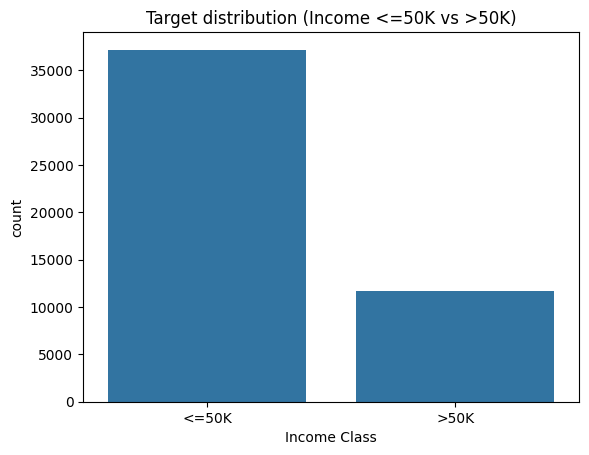

In [ ]:
target_col = 'class'

sns.countplot(x=target_col, data=df)
plt.title('Target distribution (Income <=50K vs >50K)')
plt.xlabel('Income Class (class)')

## 5. Feature Exploration

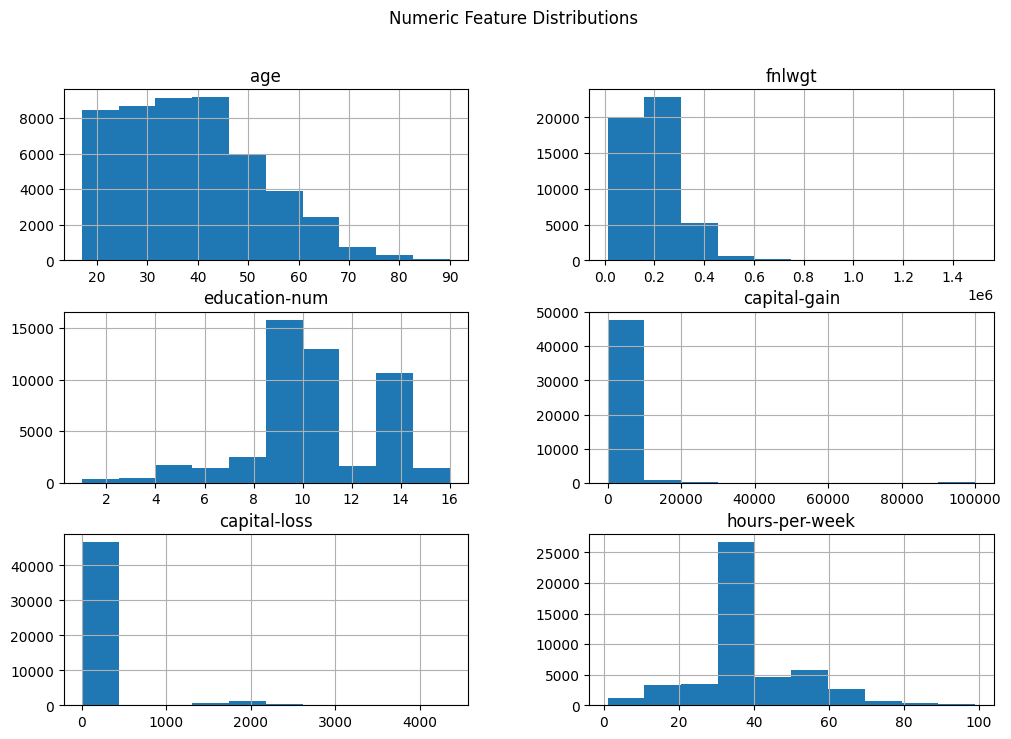

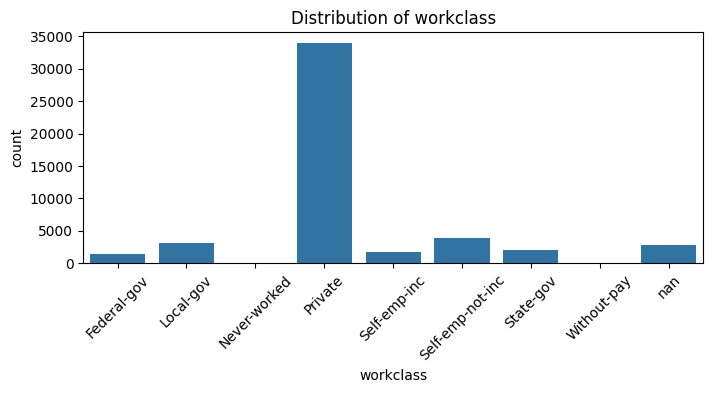

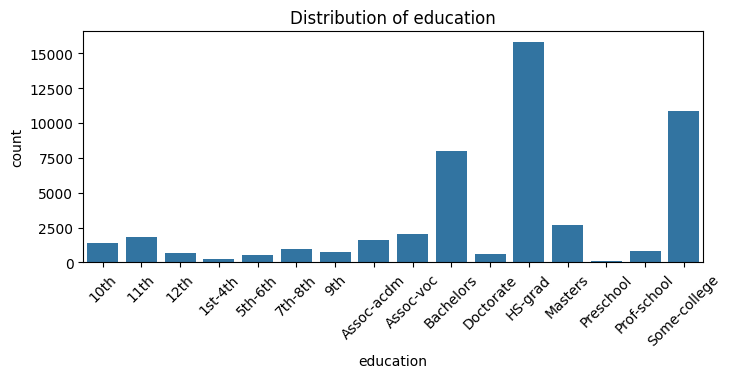

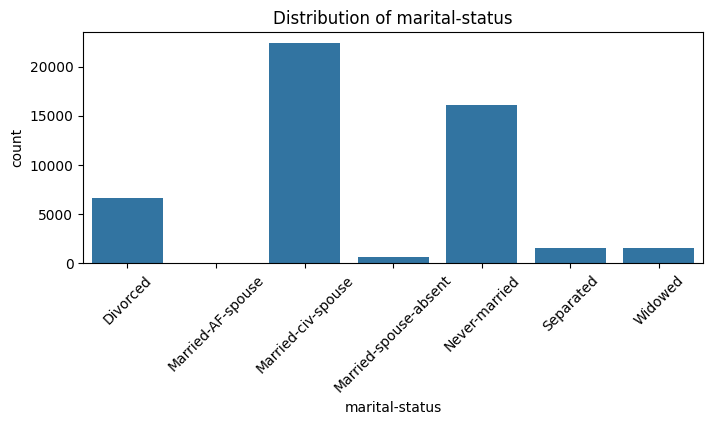

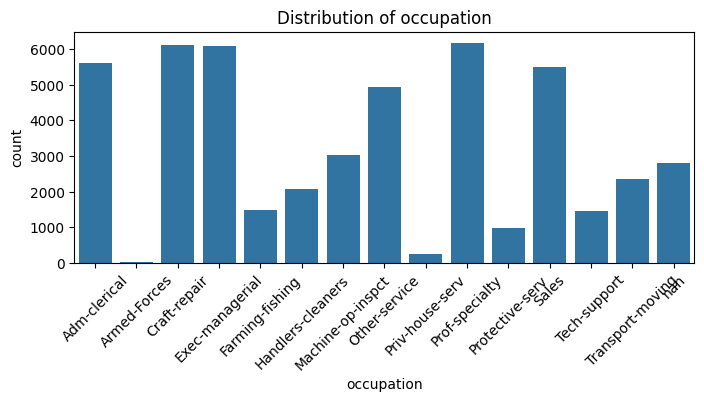

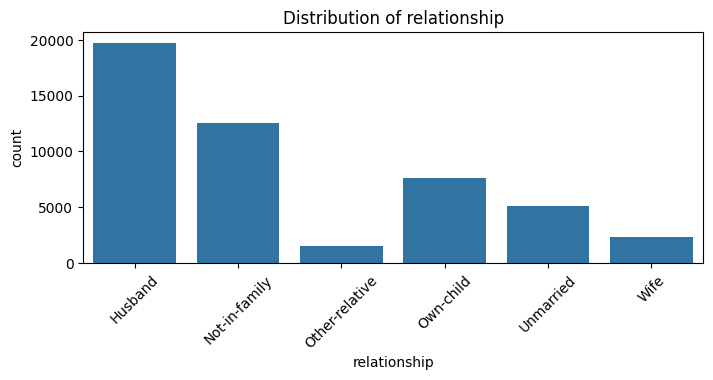

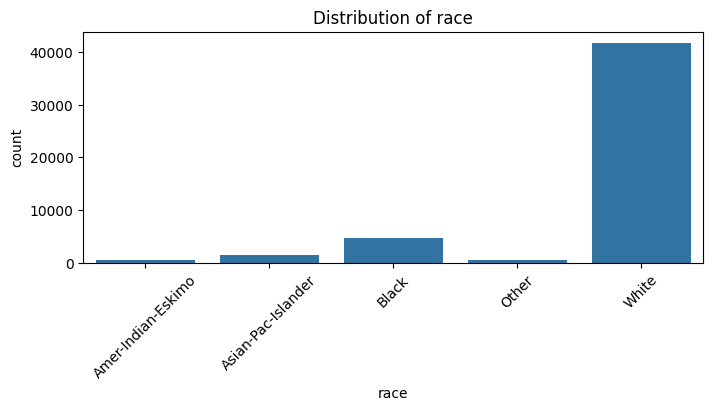

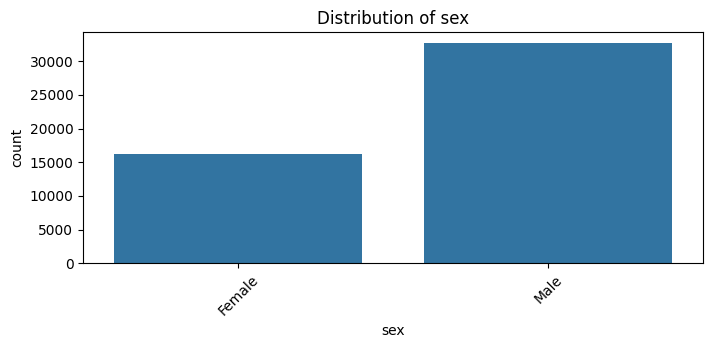

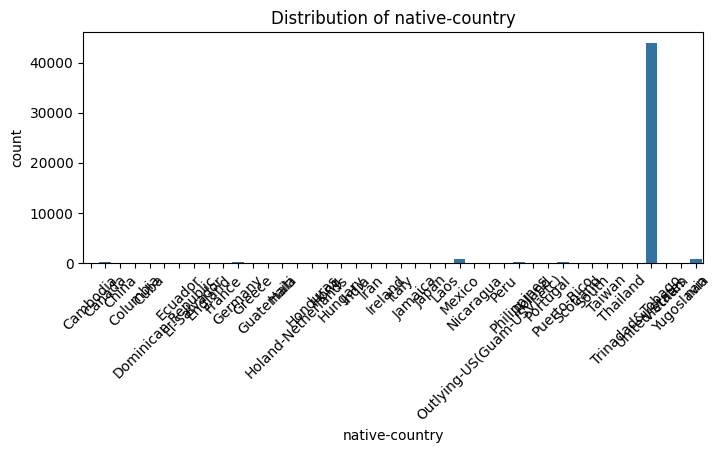

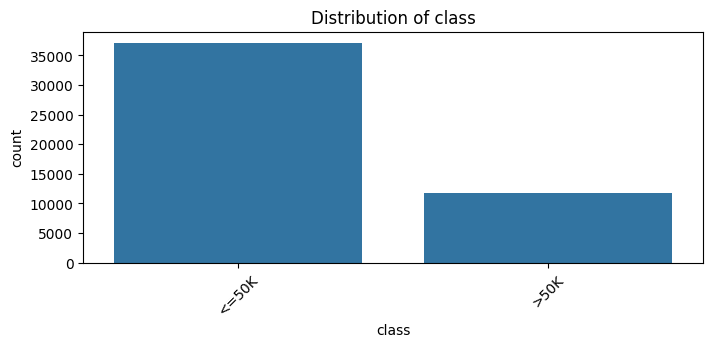

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


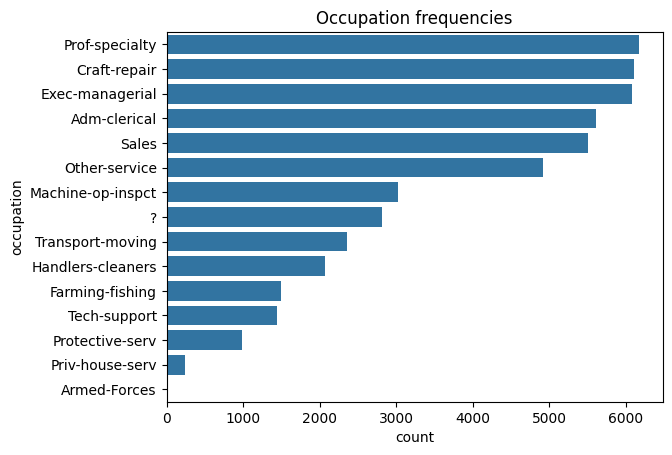

In [19]:
sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index)
plt.title('Occupation frequencies')
plt.show()

In [21]:
df.var(numeric_only=True).sort_values(ascending=True)


education-num    6.609901e+00
fnlwgt           1.115221e+10
dtype: float64

In [22]:
for col in df.select_dtypes('object'):
    print(df[col].value_counts(normalize=True).head())

age
1    0.260411
2    0.244707
0    0.197105
3    0.169854
4    0.127923
Name: proportion, dtype: float64
workclass
Private             0.694198
Self-emp-not-inc    0.079071
Local-gov           0.064207
?                   0.057307
State-gov           0.040559
Name: proportion, dtype: float64
education
HS-grad         0.323164
Some-college    0.222718
Bachelors       0.164305
Masters         0.054400
Assoc-voc       0.042197
Name: proportion, dtype: float64
marital-status
Married-civ-spouse    0.458192
Never-married         0.329982
Divorced              0.135805
Separated             0.031325
Widowed               0.031080
Name: proportion, dtype: float64
occupation
Prof-specialty     0.126367
Craft-repair       0.125138
Exec-managerial    0.124606
Adm-clerical       0.114881
Sales              0.112690
Name: proportion, dtype: float64
relationship
Husband          0.403669
Not-in-family    0.257627
Own-child        0.155215
Unmarried        0.104930
Wife             0.047725
Name: p

<Axes: xlabel='workclass', ylabel='count'>

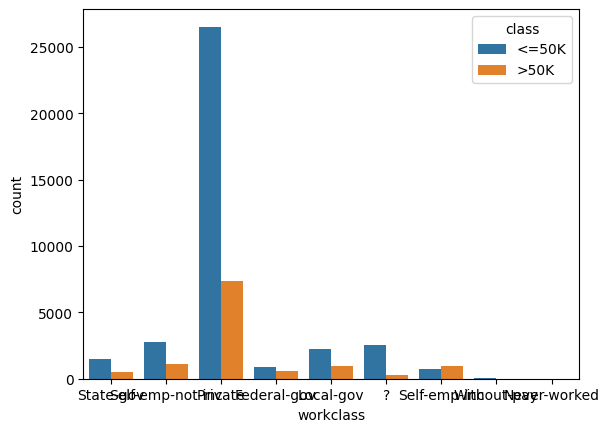

In [28]:
sns.countplot(x='workclass', hue='class', data=df)

## 6. Preprocessing Notes

In [ ]:
# - Handle missing values
# - Normalize / scale numeric features
# - Encode categorical features

# Example: Standard scaling
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)


## 7. Summary

<Axes: ylabel='Frequency'>

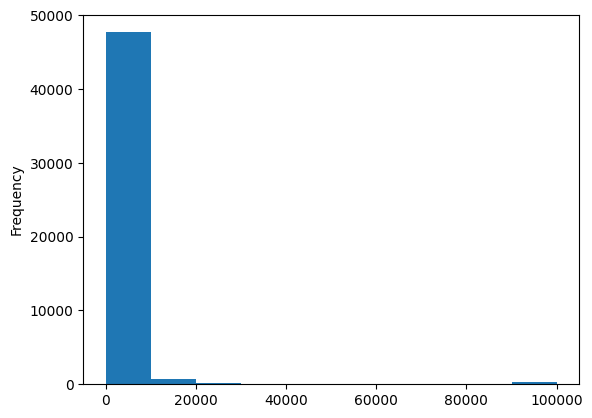

In [ ]:
# Summarize dataset characteristics and preprocessing needs here
